# 1. 线性回归（简化模型）

![](Learn_Pictures/05-线性回归+基础优化算法/img.png)

![](Learn_Pictures/05-线性回归+基础优化算法/img_1.png)

# 2. 神经网络

![](Learn_Pictures/05-线性回归+基础优化算法/img_2.png)

![](Learn_Pictures/05-线性回归+基础优化算法/img_3.png)

# 3. 线性回归（求最优解）

![](Learn_Pictures/05-线性回归+基础优化算法/img_4.png)
![](Learn_Pictures/05-线性回归+基础优化算法/img_5.png)
![](Learn_Pictures/05-线性回归+基础优化算法/img_6.png)
![](Learn_Pictures/05-线性回归+基础优化算法/img_7.png)

# 4. 线性回归（总结）

![](Learn_Pictures/05-线性回归+基础优化算法/img_8.png)

# 5. 优化方法
## 5.1 梯度下降法

![](Learn_Pictures/05-线性回归+基础优化算法/img_9.png)
![](Learn_Pictures/05-线性回归+基础优化算法/img_10.png)
![](Learn_Pictures/05-线性回归+基础优化算法/img_11.png)

## 5.2 小批量随即梯度下降法

![](Learn_Pictures/05-线性回归+基础优化算法/img_12.png)

## 5.3 选择批量大小

![](Learn_Pictures/05-线性回归+基础优化算法/img_13.png)

## 5.4 总结

![](Learn_Pictures/05-线性回归+基础优化算法/img_14.png)
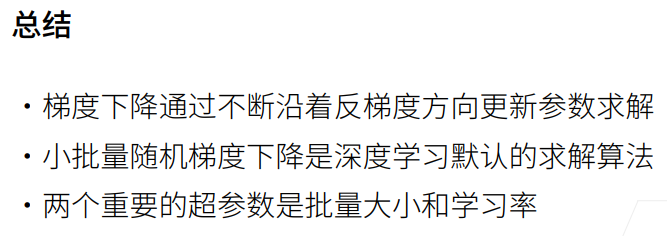

# 6. 线性回归（使用自定义）
将从零开始实现整个方法，包括数据流水线、模型、损失函数和小批量随即梯度下降优化器。
## 6.1 生成数据集
根据带有噪声的线性模型构造一个人造数据集。我们使用线性模型参数$\mathbf{w} = [2, -3.4]^\top$、$b = 4.2$和噪声项ϵ生成数据集及其标签：$\mathbf{y}= \mathbf{X} \mathbf{w} + b + \mathbf\epsilon$。

In [2]:
# 在 Jupyter Notebook 中配置 matplotlib 使其内联显示图表（图表直接嵌入在单元格输出中）
%matplotlib inline

# 导入必要的库
import random           # 用于随机操作
import torch            # PyTorch 深度学习框架
from d2l import torch as d2l  # Dive into Deep Learning (d2l) 库的 PyTorch 实现，提供实用工具函数

def synthetic_data(w, b, num_examples):
    """
    生成一个合成的线性回归数据集：y = Xw + b + 噪声

    参数:
    w (torch.Tensor): 真实的权重向量 (维度为 [n])
    b (float): 真实的偏置项
    num_examples (int): 要生成的数据样本数量

    返回:
    x (torch.Tensor): 特征矩阵 (维度为 [num_examples, len(w)])
    y (torch.Tensor): 标签向量 (维度为 [num_examples, 1])
    """
    # 生成特征矩阵 x：从标准正态分布采样，形状为 [num_examples, len(w)]
    x = torch.normal(0, 1, (num_examples, len(w)))

    # 计算标签 y = x * w + b，使用矩阵乘法
    y = torch.matmul(x, w) + b

    # 添加高斯噪声：均值为0，标准差为0.01，形状与 y 相同
    y += torch.normal(0, 0.01, y.shape)

    # 将 y 重塑为列向量 [num_examples, 1] 并返回 x 和 y
    return x, y.reshape((-1, 1))

# 定义真实的模型参数
true_w = torch.tensor([2, -3.4])  # 权重向量 [w1, w2]
true_b = -4.2                     # 偏置项

# 生成1000个样本的合成数据集
features, labels = synthetic_data(true_w, true_b, 1000)

# 打印特征矩阵和标签向量的形状
print("features.shape:", features.shape)  # 输出: torch.Size([1000, 2])
print("labels.shape:", labels.shape)      # 输出: torch.Size([1000, 1])

features.shape: torch.Size([1000, 2])
labels.shape: torch.Size([1000, 1])


## 6.2 绘制数据集
    features中每一行都包含一个二维数据样本，labels中的每一行都包含一维标签值（一个标签）。

features: tensor([-1.5312, -1.8282])
labels: tensor([-1.0505])


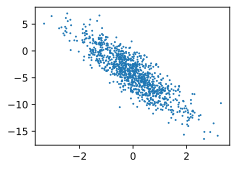

In [3]:
# 打印第一个样本的特征和标签值
print('features:', features[0])  # 输出第一个样本的特征值 (2个特征)
print('labels:', labels[0])      # 输出第一个样本的标签值

# 设置图表大小（来自d2l库的实用函数）
d2l.set_figsize()

# 创建散点图：显示第二个特征与标签的关系
# 参数说明：
#   features[:, 1]: 取所有样本的第二个特征 (x₂)
#   detach().numpy(): 从计算图中分离并转为NumPy数组（matplotlib需要）
#   1: 散点的大小为1
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1)


## 6.3 读取小批量

In [7]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

def synthetic_data(w,b,num_exaples):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0,1,(num_exaples,len(w)))
    y = torch.matmul(X,w) + b
    y += torch.normal(0,0.01,y.shape)
    return X, y.reshape((-1,1))

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:',features[0],'\nlabel:',labels[0])

d2l.set_figsize()
# d2l.plt.scatter(features[:,(1)].detach().numpy(),labels.detach().numpy(),1)


# 定义一个数据迭代器函数，用于生成小批量数据
def data_iter(batch_size, features, labels):
    """
    参数:
    batch_size (int): 每批数据的样本数量
    features (torch.Tensor): 特征矩阵 (形状: [样本数, 特征数])
    labels (torch.Tensor): 标签向量 (形状: [样本数, 1])

    功能:
    将数据集随机打乱顺序后，分批生成小批量数据
    """

    # 获取数据集的样本数量
    num_examples = len(features)  # len(features) 返回样本行数

    # 创建样本索引列表 [0, 1, 2, ..., num_examples-1]
    indices = list(range(num_examples))

    # 随机打乱索引顺序 - 确保每个epoch遍历数据的顺序不同
    # 这对机器学习训练很重要，避免模型记忆样本顺序
    random.shuffle(indices)

    # 循环遍历整个数据集，每次前进batch_size个样本
    for i in range(0, num_examples, batch_size):
        # 计算当前批次的结束位置（避免超出索引范围）
        end_idx = min(i + batch_size, num_examples)

        # 获取当前批次的索引切片
        batch_indices = indices[i:end_idx]

        # 将列表转为PyTorch张量（这步是可选的，有时直接用列表索引也可以）
        batch_indices = torch.tensor(batch_indices)

        # 使用生成器yield返回当前批次的特征和标签
        # yield 使该函数成为生成器，每次迭代时返回一个批次的数据
        yield features[batch_indices], labels[batch_indices]

# 设置批量大小
batch_size = 10

# 使用数据迭代器获取第一个小批量数据
for X, y in data_iter(batch_size, features, labels):
    # 打印当前批次的特征 (10个样本，每个样本有2个特征)
    print('特征矩阵 X:')
    print(X)

    # 打印当前批次对应的标签 (10个样本的标签)
    print('\n标签向量 y:')
    print(y)

    # 只需要第一个批次，完成后立即跳出循环
    break

features: tensor([-0.4030,  0.7153]) 
label: tensor([0.9620])
特征矩阵 X:
tensor([[ 1.0751,  0.0849],
        [-0.8425, -1.0392],
        [-0.4141, -1.4881],
        [ 0.2726, -0.7780],
        [ 1.8921, -0.2774],
        [ 0.2434, -1.2111],
        [-1.2480,  0.2619],
        [ 0.0064, -1.1913],
        [ 1.6829, -0.2618],
        [ 1.1187,  0.7017]])

标签向量 y:
tensor([[6.0580],
        [6.0398],
        [8.4535],
        [7.3901],
        [8.9372],
        [8.8138],
        [0.8206],
        [8.2680],
        [8.4788],
        [4.0519]])


## 6.4 完整模型

In [ ]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

def synthetic_data(w,b,num_exaples):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0,1,(num_exaples,len(w)))
    y = torch.matmul(X,w) + b
    y += torch.normal(0,0.01,y.shape)
    return X, y.reshape((-1,1))

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:',features[0],'\nlabel:',labels[0])

d2l.set_figsize()
d2l.plt.scatter(features[:,(1)].detach().numpy(),labels.detach().numpy(),1)

def data_iter(batch_size,features,labels):
    num_examples = len(features)  # 样本个数
    indices = list(range(num_examples)) # 样本索引
    # 这些样本是随即读取的，没有特定的顺序
    random.shuffle(indices) # 把索引随即打乱
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size,num_examples)]) # 当i+batch_size超出时，取num_examples
        yield features[batch_indices], labels[batch_indices] # 获得随即顺序的特征，及对应的标签

batch_size = 10
for X,y in data_iter(batch_size, features, labels):
    print(X, '\n', y) # 取一个批次后，就break跳出了
    break

# 定义初始化模型参数
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

# 定义模型
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b